In [1]:
import mlflow
import numpy as np
import pylab as plt
import pandas as pd

In [2]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/mlflow/perf_dal /home/dhuseljic/mlflow

receiving incremental file list
perf_dal/
perf_dal/decision_flips.db

sent 24,971 bytes  received 530,876 bytes  222,338.80 bytes/sec
total size is 18,391,040  speedup is 33.09


In [7]:
# client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:///decision_flips.db')
# experiment_id = client.get_experiment_by_name('decision_flips').experiment_id
client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:////home/dhuseljic/mlflow/perf_dal/decision_flips.db')
experiment_id = client.get_experiment_by_name('decision_flips_v5').experiment_id
query_list = [
    "parameter.dataset_name= 'cifar10'",
    # "parameter.min_train_samples = '10'",
    # "parameter.max_train_samples = '300'",
    "parameter.max_new_samples= '10'",
]
runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs)))

Found 50 experiments


In [8]:
from collections import defaultdict
all_results = defaultdict(list)
for run in runs:
    num_train_samples = [m.value for m in client.get_metric_history(run.info.run_id, 'num_train_samples')]
    num_new_samples = [m.value for m in client.get_metric_history(run.info.run_id, 'num_new_samples')]
    accuracy = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    accuracy_new = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy_new')]
    decision_flips = [m.value for m in client.get_metric_history(run.info.run_id, 'decision_flips')]

    all_results['num_train_samples'].append(num_train_samples)
    all_results['num_new_samples'].append(num_new_samples)
    all_results['accuracy'].append(accuracy)
    all_results['accuracy_new'].append(accuracy_new)
    all_results['decision_flips'].append(decision_flips)

In [9]:
num_train_samples = np.mean(all_results['num_train_samples'], 0)
num_new_samples = np.mean(all_results['num_new_samples'], 0)
accuracy = np.mean(all_results['accuracy'], 0)
accuracy_new = np.mean(all_results['accuracy_new'], 0)
decision_flips = np.mean(all_results['decision_flips'], 0)
decision_flips_std = np.std(all_results['decision_flips'], 0)

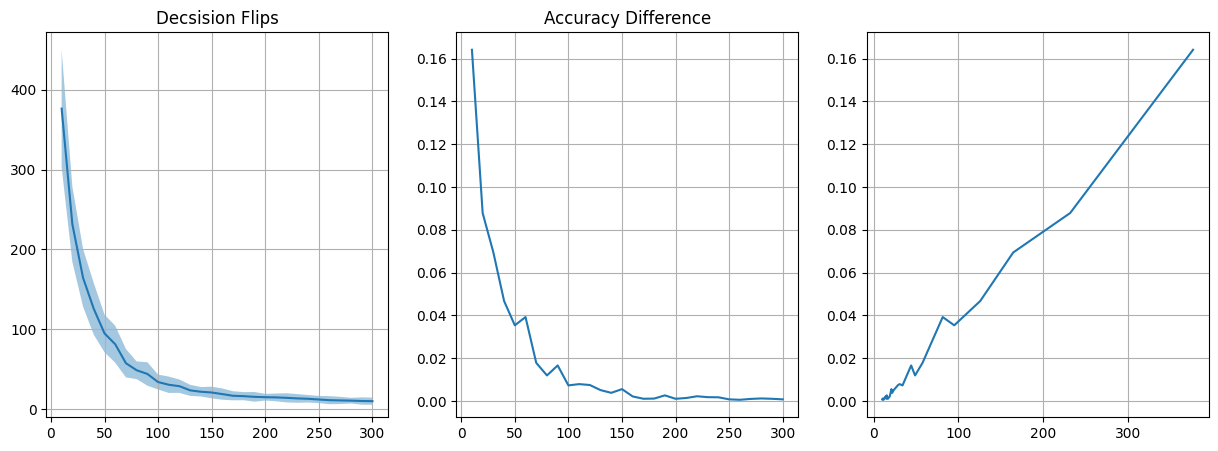

In [10]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title('Decision Flips')
plt.plot(num_train_samples, decision_flips, '-')
plt.fill_between(num_train_samples, decision_flips-decision_flips_std, decision_flips+decision_flips_std, alpha=.4)
plt.ylim(bottom=-10)
plt.grid()

plt.subplot(132)
plt.title('Accuracy Difference')
plt.plot(num_train_samples, accuracy_new - accuracy, '-')
plt.grid()

plt.subplot(133)
plt.plot(decision_flips, accuracy_new - accuracy, '-')
plt.grid()
plt.show()